In [1]:
%pip install matplotlib 

  Using cached matplotlib-3.10.9-cp314-cp314-win_amd64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp314-cp314-win_amd64.whl.metadata (121 kB)
  Using cached kiwisolver-1.5.0-cp314-cp314-win_amd64.whl.metadata (5.2 kB)
  Using cached numpy-2.4.6-cp314-cp314-win_amd64.whl.metadata (6.6 kB)
Using cached matplotlib-3.10.9-cp314-cp314-win_amd64.whl (8.3 MB)
Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl (232 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.63.0-cp314-cp314-win_amd64.whl (2.3 MB)
Using cached kiwisolver-1.5.0-cp314-cp314-win_amd64.whl (75 kB)
Using cached numpy-2.4.6-cp314-cp314-win_amd64.whl (12.5 MB)

   ---------------------------------------- 0/6 [numpy]
   ---------------------------------------- 0/6 [numpy]
   ---------------------------------------- 0/6 [numpy]
   -----------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


Matplotlib is building the font cache; this may take a moment.


Enquação da reta: y^ = -43580.743094 + 280.623568 * x
Coeficiente de correlação (r): 0.702035
Coeficiente de determinação (R²): 0.492853


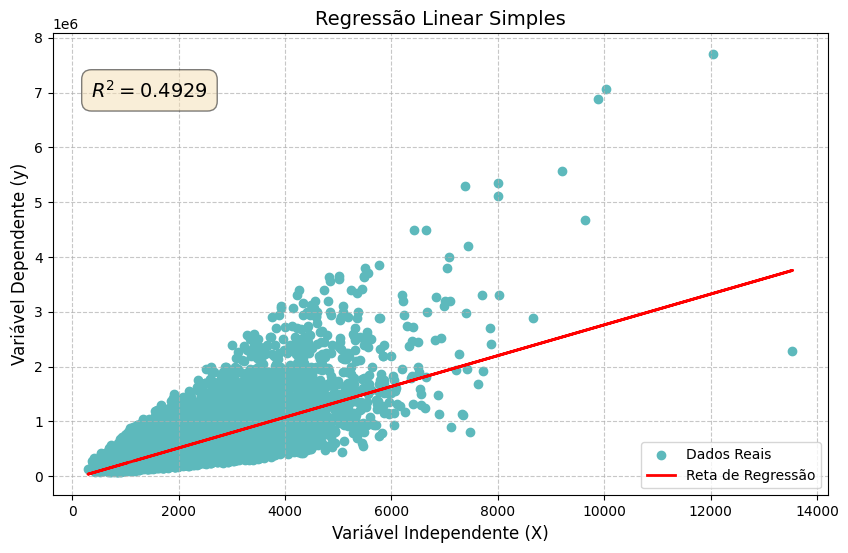

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

#from google.colab import files
#uploaded = files.upload()

#1. Leitura dos dados do arquivo CSV usando numpy
#Ignoramos a primeira linha (skip_header=1) pois ela contém cabeçalhos 'x,y'
dados = np.genfromtxt('kc_house_data.csv', delimiter=',', skip_header=1, usecols=(5,2))
x = dados[:,0 ] #variável independente: sqft_living
y = dados[:,1 ] #variável dependente: price
n = len(x) #quantidade de amostras


#2. Cálculo dos somatórios necessários para fórmulas 
sum_x = np.sum(x)
sum_y = np.sum(y)
sum_xy = np.sum(x*y)
sum_x2 = np.sum(x**2)
sum_y2 = np.sum(y**2)

#3. Cálculo da reta da regrresão (y_hat = a + b*x)
#Calculando o coeficiente 'b'
b = (n * sum_xy - sum_x * sum_y) / (n * sum_x2 - sum_x**2)

#Calculando o coeficiente 'a'
a = (sum_y - b * sum_x) / n

#Gerando os valores previstos (y_hat)
y_hat = a + b * x

#4. Cálculo do coeficiente de correlação de Perarson (r)
numerador_r = n * sum_xy - (sum_x * sum_y)
denominador_r = np.sqrt(n * sum_x2 - sum_x**2) * np.sqrt(n * sum_y2 - sum_y**2)
r = numerador_r / denominador_r

#5. Cálculo do coeficiente de determinação (R²)
y_mean = np.mean(y)
#Formula: Somatorio de (y_hat - y_mean)² dividido pelo somatorio de (y - y_mean)²
sq_reg = np.sum((y_hat - y_mean)**2)
sq_tot = np.sum((y - y_mean)**2)
r2 = sq_reg / sq_tot

#6. Exibição dos resultados de controle
print(f"Enquação da reta: y^ = {a:4f} + {b:4f} * x")
print(f"Coeficiente de correlação (r): {r:4f}")
print(f"Coeficiente de determinação (R²): {r2:4f}")

#7. Visualização gráfica dos dados
plt.figure(figsize=(10, 6))

#Gráfico de disperção (Scatter plot) dos dados reais
plt.scatter(x, y, color='#5DB9BC', label='Dados Reais')

#Plotando a reta de regressão 
plt.plot(x, y_hat, color='red', linewidth=2, label='Reta de Regressão')

#Configurações de layout de gráfico
plt.title('Regressão Linear Simples', fontsize=14)
plt.xlabel('Sqft Living (X - Variável Independente)', fontsize=12)
plt.ylabel('Preço (y - Variável Dependente)', fontsize=12)

#Adicionar o valor de R² ao gráfico para fácil visualização 
plt.text(0.05, 0.9, f'$R^2 = {r2:.4f}$', transform=plt.gca().transAxes, fontsize=14, verticalalignment='top', bbox=dict(boxstyle='round,pad=0.5', fc='wheat', alpha=0.5))

plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()